In [1]:
from matplotlib import pyplot as plt
import numpy as np

Processing 1500 FITS files from ./data/251227/zenith_1
Loaded 1500 FITS files from ./data/251227/zenith_1


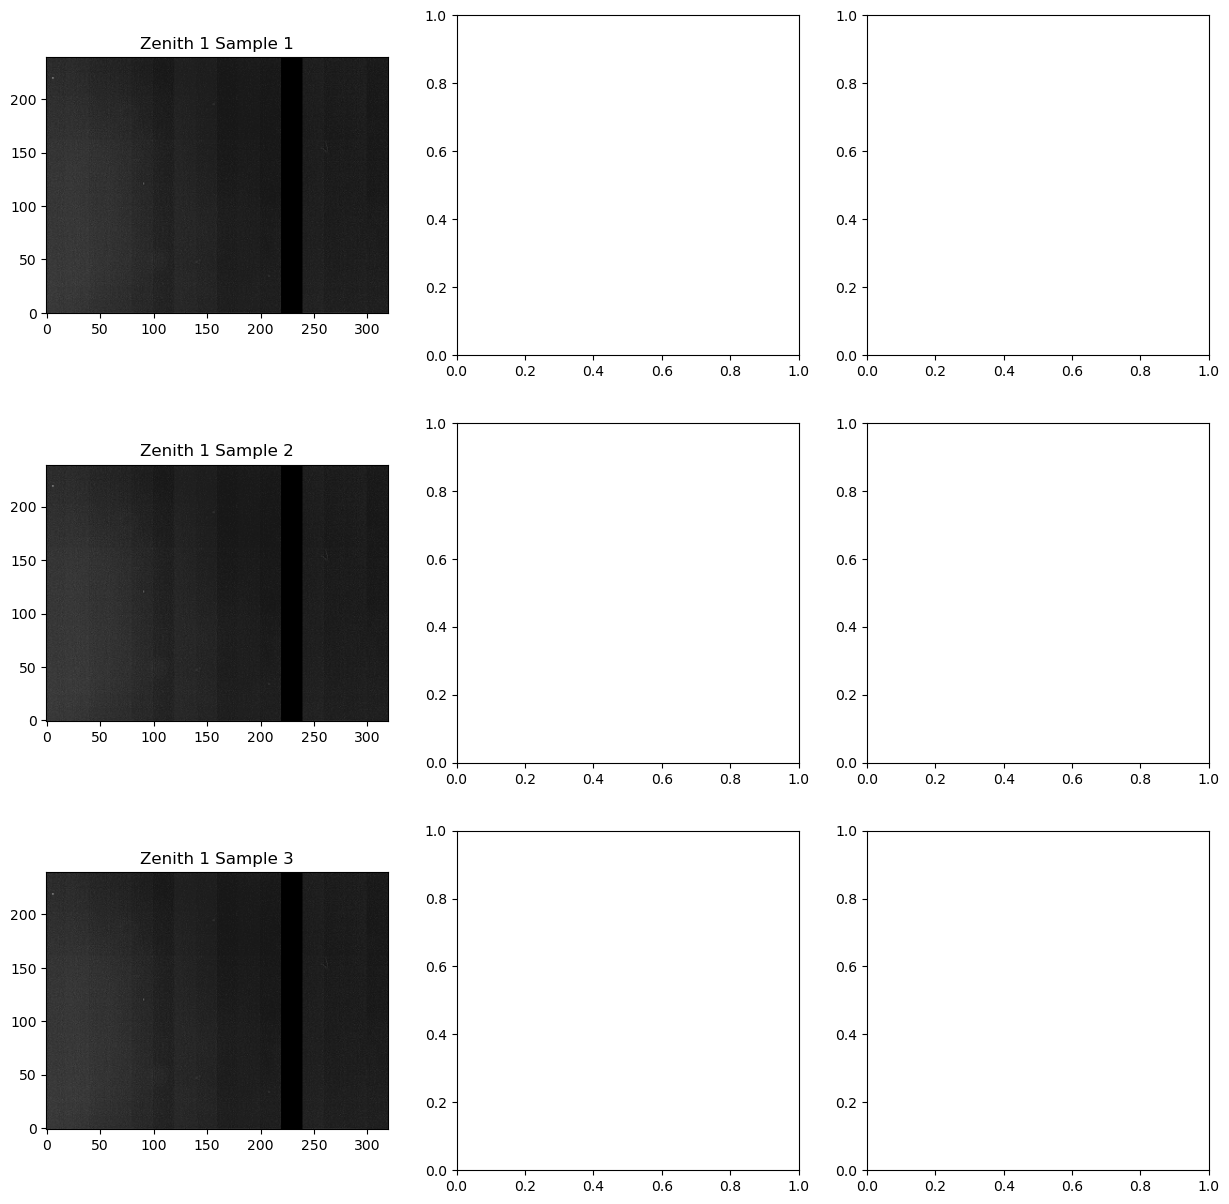

In [2]:
# Read in the data from the fits file 
from test_analysis import read_in_fits
zenith_1_data = read_in_fits('./data/251227/zenith_1')
# display three random images from each to make sure it loaded in correctly
test_fig, test_axs = plt.subplots(3,3, figsize=(15,15))
for i, data in enumerate([zenith_1_data]):
    for j in range(3):
        test_axs[j,i].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[j,i].set_title(f'Zenith {i+1} Sample {j+1}')
plt.show()


In [3]:
# Maake an aperture in box that fits in one vertical strip (since the data is scrambled in vertical strips of 20 pixels)

ap = 10
x_center = 50
y_center = 100
x_half_width = 1

In [ ]:
import numpy as np

def descramble_mirsi_u32(sdata, rows: int, cols: int = 320, channels:
int = 16) -> np.ndarray:
    s = np.asarray(sdata, dtype=np.uint32)

    if cols != 320:
        raise ValueError("cols must be 320")
    if channels != 16:
        raise ValueError("channels must be 16")
    if cols % channels != 0:
        raise ValueError("cols must be divisible by channels")

    offset = cols // channels
    expected = rows * cols
    if s.size < expected:
        raise ValueError(f"need at least {expected} uint32 values, got {s.size}")

    s = s[:expected].reshape(rows, cols)

    d = s.reshape(rows, offset, channels).transpose(0, 2, 1).reshape(rows, cols)
    d = d[:, ::-1]

    d[:, 80:100] = d[:, 0:20]
    d[:, 0:20] = 0

    return d

In [9]:
# take a random image from the list and descramble it
random_image = zenith_1_data[np.random.randint(0, zenith_1_data.shape[0])]
descrambled_image = descramble_mirsi_u32(random_image, rows=240)


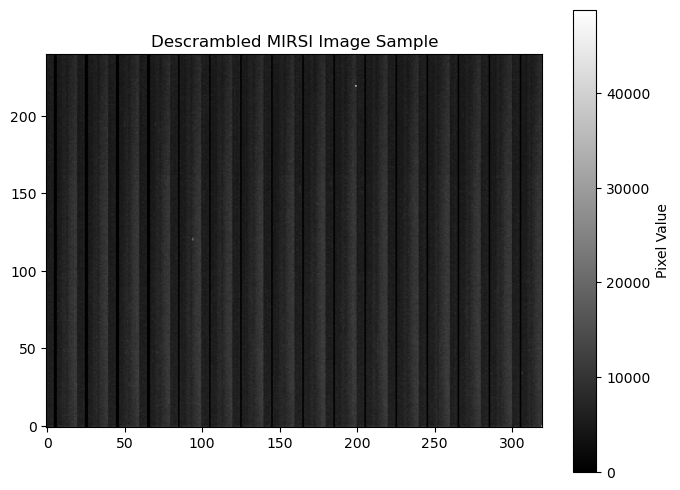

In [10]:
# Plot the descrambled image
plt.figure(figsize=(8,6))
plt.imshow(descrambled_image, cmap='gray', origin='lower')
plt.title('Descrambled MIRSI Image Sample')
plt.colorbar(label='Pixel Value')
plt.show()  

Text(0.5, 1.0, 'Pixel Values Along Rows')

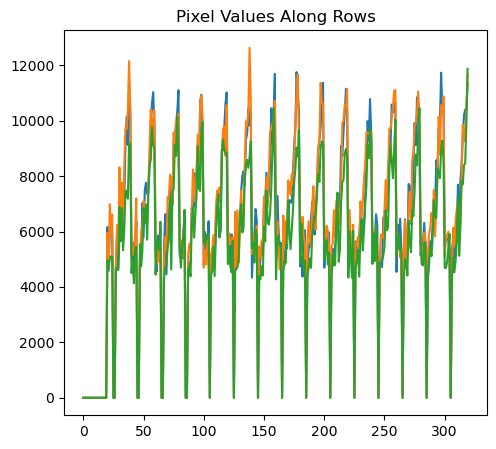

In [7]:
# draw cuts in the x and y directions to see the pixel values along those cuts
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(descrambled_image[120,:], label='Row 120')
plt.plot(descrambled_image[60,:], label='Row 60')
plt.plot(descrambled_image[180,:], label='Row 180')
plt.title('Pixel Values Along Rows')